In [0]:
%pip install python-calamine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.2/925.2 kB 21.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "/Volumes/workspace/default/walmart_data/walmart_clean.csv"

df = pd.read_csv(FILE_PATH)
df['event_ts'] = pd.to_datetime(df['event_ts'])

print(f"✅ Clean dataset loaded")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")

/home/spark-db5eb74d-12ee-49f5-a57e-ee/.ipykernel/3108/command-4982960997226643-1429327166:8: DtypeWarning: Columns (15,16,17,19,20,21,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


✅ Clean dataset loaded
   Rows    : 355,661
   Columns : 47


# 04 — Root Cause Analysis (Diagnostic Analytics)

## Goal
Move from WHAT is happening to WHY it is happening.
We already know the three problem areas from EDA:
1. Apparel brands (Wonder Nation, Faded Glory) — 37% on-time
2. Reverse Logistics — 44% on-time, 62% anomaly rate
3. Supplier-to-DC inbound — 54.8% on-time

## Diagnostic Questions
- WHY is Apparel performing so poorly? Which lifecycle stage, exception, scenario?
- WHY is Reverse Logistics broken? What are the dominant failure modes?
- WHY does the Supplier>DC channel underperform? Which suppliers, which exceptions?
- What combination of factors predicts the worst outcomes?

In [0]:
# WHY: Apparel had only 37% on-time and 64% anomaly rate.
# We need to drill into Apparel specifically and ask:
# - Which lifecycle stage is causing it?
# - Which scenario/event type is failing?
# - What exception codes appear most in Apparel?
# This is diagnostic thinking — peeling back layers until we find the root.

apparel = df[df['product_category'] == 'Apparel'].copy()

print("APPAREL DEEP DIVE")
print("=" * 55)
print(f"  Total Apparel events : {len(apparel):,}")
print(f"  On-time rate         : {(apparel['on_time_flag'] == 1).sum() / apparel['on_time_flag'].dropna().shape[0] * 100:.1f}%")
print(f"  Anomaly rate         : {apparel['anomaly_flag'].mean() * 100:.1f}%")
print(f"  Avg delay days       : {apparel['delay_days'].mean():.2f}")

# Apparel by lifecycle stage
print(f"\n  BY LIFECYCLE STAGE:")
print(f"  {'-'*50}")
app_stage = apparel.groupby('lifecycle_stage').apply(
    lambda x: pd.Series({
        'events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'anomaly_rate': x['anomaly_flag'].mean() * 100,
        'avg_delay': x['delay_days'].mean()
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=True)
print(app_stage.to_string())

# Apparel exception codes
print(f"\n  TOP EXCEPTION CODES IN APPAREL:")
print(f"  {'-'*50}")
app_exc = apparel['exception_code'].value_counts(dropna=True)
for exc, count in app_exc.items():
    pct = count / len(apparel) * 100
    print(f"  {str(exc):<30} {count:>5,}  ({pct:.1f}%)")

# Apparel by scenario
print(f"\n  TOP SCENARIOS IN APPAREL:")
print(f"  {'-'*50}")
app_scen = apparel['scenario_name'].value_counts().head(8)
for scen, count in app_scen.items():
    pct = count / len(apparel) * 100
    print(f"  {str(scen):<35} {count:>5,}  ({pct:.1f}%)")

APPAREL DEEP DIVE
  Total Apparel events : 12,341
  On-time rate         : 37.3%
  Anomaly rate         : 64.0%
  Avg delay days       : 1.38

  BY LIFECYCLE STAGE:
  --------------------------------------------------
                      events  on_time_rate  anomaly_rate  avg_delay
lifecycle_stage                                                    
SHIPMENT              3342.0          0.00        100.00       2.00
FULFILLMENT           6696.0         50.00         50.00       1.00
INVENTORY_MANAGEMENT  1388.0         54.96         55.33       2.05
FORWARD_LOGISTICS      309.0        100.00          0.00       0.00
REVERSE_LOGISTICS      383.0           NaN        100.00        NaN
SKU_MANAGEMENT         223.0           NaN         23.77       1.95

  TOP EXCEPTION CODES IN APPAREL:
  --------------------------------------------------
  SPLIT_DELAY                    6,690  (54.2%)
  SUPPLIER_DELAY                   269  (2.2%)
  CYCLE_COUNT_VAR                  260  (2.1%)
  SUPPLI

In [0]:
# WHY: Reverse Logistics had 44% on-time and 62% anomaly rate.
# Returns are complex — products come back from customers,
# get inspected, restocked or scrapped.
# Let's find exactly where in the return process things break down.

reverse = df[df['lifecycle_stage'] == 'REVERSE_LOGISTICS'].copy()

print("REVERSE LOGISTICS DEEP DIVE")
print("=" * 55)
print(f"  Total return events  : {len(reverse):,}")
print(f"  On-time rate         : {(reverse['on_time_flag'] == 1).sum() / reverse['on_time_flag'].dropna().shape[0] * 100:.1f}%")
print(f"  Anomaly rate         : {reverse['anomaly_flag'].mean() * 100:.1f}%")
print(f"  Revenue leakage rate : {reverse['revenue_leakage_flag'].mean() * 100:.1f}%")
print(f"  Avg delay days       : {reverse['delay_days'].mean():.2f}")

# By scenario
print(f"\n  BY SCENARIO:")
print(f"  {'-'*55}")
rev_scen = reverse.groupby('scenario_name').apply(
    lambda x: pd.Series({
        'events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'anomaly_rate': x['anomaly_flag'].mean() * 100,
        'revenue_leakage_rate': x['revenue_leakage_flag'].mean() * 100,
        'avg_delay': x['delay_days'].mean()
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=True)
print(rev_scen.to_string())

# By exception code
print(f"\n  TOP EXCEPTION CODES IN REVERSE LOGISTICS:")
print(f"  {'-'*55}")
rev_exc = reverse['exception_code'].value_counts(dropna=True)
for exc, count in rev_exc.items():
    pct = count / len(reverse) * 100
    print(f"  {str(exc):<30} {count:>5,}  ({pct:.1f}%)")

# By reverse status
print(f"\n  REVERSE STATUS AFTER:")
print(f"  {'-'*55}")
rev_status = reverse['reverse_status_after'].value_counts(dropna=False)
for status, count in rev_status.items():
    pct = count / len(reverse) * 100
    print(f"  {str(status):<20} {count:>5,}  ({pct:.1f}%)")

REVERSE LOGISTICS DEEP DIVE
  Total return events  : 44,114
  On-time rate         : 44.1%
  Anomaly rate         : 61.7%
  Revenue leakage rate : 48.6%
  Avg delay days       : 1.34

  BY SCENARIO:
  -------------------------------------------------------
                            events  on_time_rate  anomaly_rate  revenue_leakage_rate  avg_delay
scenario_name                                                                                  
DAMAGED_IN_TRANSIT_RETURN   8489.0           0.0         100.0                 100.0        3.0
SALE_DISPUTE_RETURN        12955.0           0.0         100.0                 100.0        2.0
BUYERS_REMORSE_RETURN      16912.0         100.0           0.0                   0.0        0.0
AGED_STOCK_SCRAP            2896.0           NaN         100.0                   0.0        NaN
STORE_RETURN_TO_DC          2862.0           NaN         100.0                   0.0        NaN

  TOP EXCEPTION CODES IN REVERSE LOGISTICS:
  ------------------------

In [0]:
# WHY: SUPPLIER>DC channel had only 54.8% on-time and 2.17 day avg delay.
# This is the inbound supply chain — before products even reach Walmart's warehouse.
# Let's find which suppliers, which exception codes, and which scenarios
# are driving this underperformance.

supplier_dc = df[df['channel_path'] == 'SUPPLIER>DC'].copy()

print("SUPPLIER > DC CHANNEL DEEP DIVE")
print("=" * 55)
print(f"  Total events   : {len(supplier_dc):,}")
print(f"  On-time rate   : {(supplier_dc['on_time_flag'] == 1).sum() / supplier_dc['on_time_flag'].dropna().shape[0] * 100:.1f}%")
print(f"  Avg delay days : {supplier_dc['delay_days'].mean():.2f}")
print(f"  Anomaly rate   : {supplier_dc['anomaly_flag'].mean() * 100:.1f}%")

# By supplier
print(f"\n  BY SUPPLIER:")
print(f"  {'-'*55}")
sup_perf = supplier_dc.groupby('supplier_name').apply(
    lambda x: pd.Series({
        'events': len(x),
        'on_time_rate': (x['on_time_flag'] == 1).sum() / x['on_time_flag'].dropna().shape[0] * 100 if x['on_time_flag'].dropna().shape[0] > 0 else None,
        'avg_delay': x['delay_days'].mean(),
        'anomaly_rate': x['anomaly_flag'].mean() * 100
    }), include_groups=False
).round(2).sort_values('on_time_rate', ascending=True)
print(sup_perf.to_string())

# By exception code
print(f"\n  EXCEPTION CODES IN SUPPLIER>DC:")
print(f"  {'-'*55}")
sup_exc = supplier_dc['exception_code'].value_counts(dropna=True)
for exc, count in sup_exc.items():
    pct = count / len(supplier_dc) * 100
    print(f"  {str(exc):<30} {count:>5,}  ({pct:.1f}%)")

# By scenario
print(f"\n  SCENARIOS IN SUPPLIER>DC:")
print(f"  {'-'*55}")
sup_scen = supplier_dc['scenario_name'].value_counts()
for scen, count in sup_scen.items():
    pct = count / len(supplier_dc) * 100
    print(f"  {str(scen):<35} {count:>5,}  ({pct:.1f}%)")

SUPPLIER > DC CHANNEL DEEP DIVE
  Total events   : 17,371
  On-time rate   : 54.8%
  Avg delay days : 2.17
  Anomaly rate   : 45.2%

  BY SUPPLIER:
  -------------------------------------------------------
                         events  on_time_rate  avg_delay  anomaly_rate
supplier_name                                                         
Samsung Electronics      1558.0         52.57       2.24         47.43
HP Inc.                  1402.0         54.07       2.34         45.93
Fresh Produce Supplier   2517.0         55.07       2.21         44.93
Walmart Private Label   10782.0         55.10       2.13         44.90
Apple Inc.               1112.0         55.22       2.17         44.78

  EXCEPTION CODES IN SUPPLIER>DC:
  -------------------------------------------------------
  SUPPLIER_DELAY                 4,321  (24.9%)
  SUPPLIER_SHORT_SHIP            3,532  (20.3%)

  SCENARIOS IN SUPPLIER>DC:
  -------------------------------------------------------
  SUPPLIER_TO_DC_STAN

CORRELATION WITH DELAY_DAYS
(+1 = strong positive, -1 = strong negative, 0 = no relationship)

  anomaly_flag               0.835  █████████████████████████
  has_exception              0.835  █████████████████████████
  is_delayed                 0.835  █████████████████████████
  customer_impact_score      0.612  ██████████████████
  actual_cycle_days          0.501  ███████████████
  inventory_delta            0.471  ██████████████
  qty                        0.470  ██████████████
  revenue_leakage_flag       0.437  █████████████
  margin                    -0.021  
  sell_price                -0.021  
  unit_cost                 -0.021  


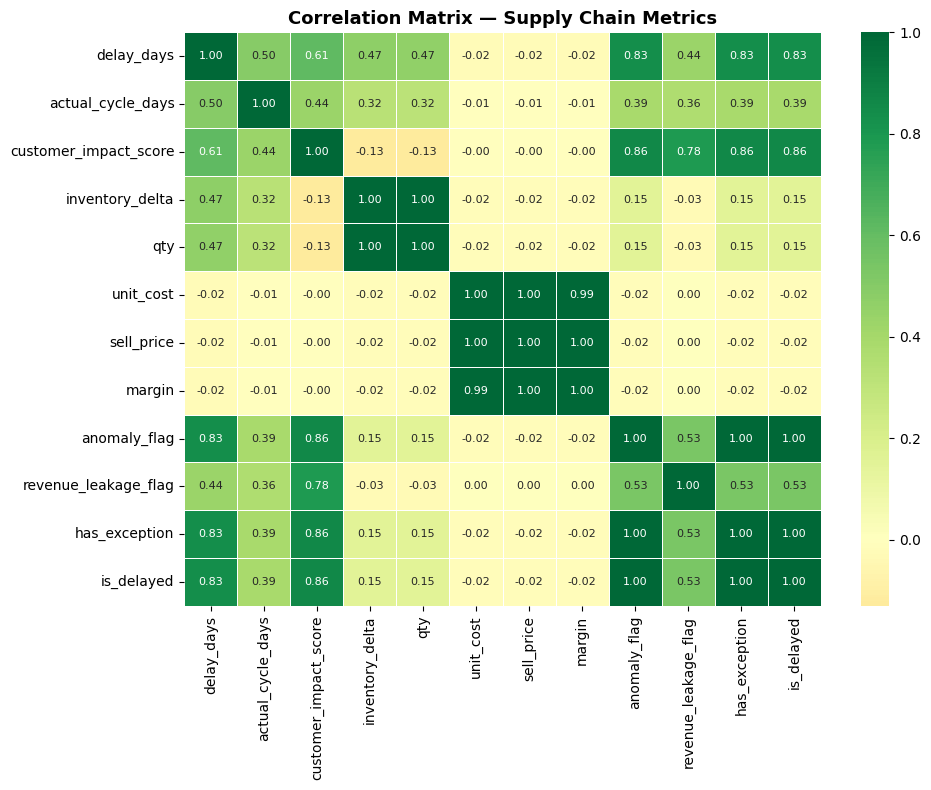

In [0]:
# WHY: So far we've looked at one variable at a time.
# Correlation analysis asks: which numeric factors MOVE TOGETHER with delay_days?
# This tells us what to control to reduce delays.
# It's one of the most important diagnostic tools in data analysis.

# Select numeric columns relevant to delay
corr_cols = [
    'delay_days', 'actual_cycle_days', 'customer_impact_score',
    'inventory_delta', 'qty', 'unit_cost', 'sell_price',
    'margin', 'anomaly_flag', 'revenue_leakage_flag',
    'has_exception', 'is_delayed'
]

corr_data = df[corr_cols].dropna()
corr_matrix = corr_data.corr()

# Focus on correlations WITH delay_days specifically
delay_corr = corr_matrix['delay_days'].drop('delay_days').sort_values(ascending=False)

print("CORRELATION WITH DELAY_DAYS")
print("=" * 50)
print("(+1 = strong positive, -1 = strong negative, 0 = no relationship)")
print()
for col, val in delay_corr.items():
    bar_len = int(abs(val) * 30)
    direction = '█' if val > 0 else '░'
    bar = direction * bar_len
    print(f"  {col:<25} {val:>6.3f}  {bar}")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Supply Chain Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [0]:
# WHY: A powerful diagnostic technique is comparing two groups —
# delayed events vs on-time events — and asking "what's different?"
# The differences between these groups reveal what drives delays.

on_time_events = df[df['on_time_flag'] == 1]
delayed_events = df[df['on_time_flag'] == 0]

print("DELAYED vs ON-TIME EVENTS — COMPARISON")
print("=" * 60)
print(f"  On-time events : {len(on_time_events):,}")
print(f"  Delayed events : {len(delayed_events):,}")

print(f"\n  NUMERIC DIFFERENCES:")
print(f"  {'-'*55}")
compare_cols = ['delay_days', 'actual_cycle_days', 'qty',
                'customer_impact_score', 'inventory_delta', 'margin']

comparison = pd.DataFrame({
    'On-Time Mean': on_time_events[compare_cols].mean(),
    'Delayed Mean': delayed_events[compare_cols].mean()
}).round(2)
comparison['Difference'] = (comparison['Delayed Mean'] - comparison['On-Time Mean']).round(2)
comparison['% Worse'] = ((comparison['Difference'] / comparison['On-Time Mean']) * 100).round(1)
print(comparison.to_string())

print(f"\n  CATEGORICAL DIFFERENCES:")
print(f"  {'-'*55}")

# Lifecycle stage distribution
print(f"\n  Lifecycle stage — delayed events:")
delayed_stage = delayed_events['lifecycle_stage'].value_counts(normalize=True).round(3) * 100
ontime_stage = on_time_events['lifecycle_stage'].value_counts(normalize=True).round(3) * 100
stage_comp = pd.DataFrame({
    'On-Time %': ontime_stage,
    'Delayed %': delayed_stage
}).fillna(0).round(1)
stage_comp['Gap'] = (stage_comp['Delayed %'] - stage_comp['On-Time %']).round(1)
print(stage_comp.sort_values('Gap', ascending=False).to_string())

# Product category distribution
print(f"\n  Product category — delayed vs on-time:")
delayed_cat = delayed_events['product_category'].value_counts(normalize=True).round(3) * 100
ontime_cat = on_time_events['product_category'].value_counts(normalize=True).round(3) * 100
cat_comp = pd.DataFrame({
    'On-Time %': ontime_cat,
    'Delayed %': delayed_cat
}).fillna(0).round(1)
cat_comp['Gap'] = (cat_comp['Delayed %'] - cat_comp['On-Time %']).round(1)
print(cat_comp.sort_values('Gap', ascending=False).to_string())

DELAYED vs ON-TIME EVENTS — COMPARISON
  On-time events : 241,815
  Delayed events : 100,205

  NUMERIC DIFFERENCES:
  -------------------------------------------------------
                       On-Time Mean  Delayed Mean  Difference  % Worse
delay_days                     0.00          2.52        2.52      inf
actual_cycle_days              1.87          4.97        3.10    165.8
qty                            6.83         10.42        3.59     52.6
customer_impact_score         17.00         60.12       43.12    253.6
inventory_delta                5.77          9.44        3.67     63.6
margin                        41.88         39.77       -2.11     -5.0

  CATEGORICAL DIFFERENCES:
  -------------------------------------------------------

  Lifecycle stage — delayed events:
                      On-Time %  Delayed %   Gap
lifecycle_stage                                 
REVERSE_LOGISTICS           7.0       21.4  14.4
INVENTORY_MANAGEMENT        5.7       12.8   7.1
FORWARD_L

## Root Cause Analysis — Diagnostic Findings

### Root Cause 1 — Apparel Split Shipment Failure
- 81.3% of Apparel events are SPLIT_SHIPMENT_MULTI_ITEM scenario
- SPLIT_DELAY exception accounts for 54.2% of all Apparel exceptions
- Shipment lifecycle stage shows 0% on-time and 100% anomaly rate for Apparel
- Fix: Reduce order splitting or build coordination system for split shipments

### Root Cause 2 — Reverse Logistics Exception Handling Gap
- Normal buyer's remorse returns perform at 100% on-time (no problem here)
- SALE_DISPUTE and DAMAGED_IN_TRANSIT returns: 0% on-time, 100% leakage
- No effective workflow exists for handling adversarial return scenarios
- Fix: Build dedicated exception handling workflow for disputed and damaged returns

### Root Cause 3 — Inbound Supplier Delivery Reliability
- 45.2% of all supplier-to-DC events are pre-flagged as delayed or short-shipped
- All suppliers equally affected — structural industry problem, not supplier-specific
- Problems are known in advance but not proactively resolved
- Fix: Early warning system + supplier performance incentives

### Supporting Diagnostic Evidence
- Anomaly flag and delay_days correlate at 0.835 — same underlying problem
- Quantity per order correlates with delay at 0.470 — larger orders = more splits = more delays
- Customer impact score is 254% higher in delayed vs on-time events
- Apparel is 4x over-represented in delayed events vs its share of total events
- Price and margin have zero correlation with delays — purely operational problem